In [1]:
from icecube import dataclasses, dataio, icetray, simclasses
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
from icecube.phys_services import I3Calculator
import sys, os
import random
import tables
from matplotlib.ticker import ScalarFormatter

params = {'figure.figsize': (7, 7*0.618),
          'legend.fontsize': 14,
          'axes.labelsize': 16,
          'axes.titlesize': 16,
          'xtick.labelsize': 16,
          'ytick.labelsize': 16}
plt.rcParams.update(params)

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3,3))

In [2]:
# Open the HDF5 file (read-only)
file = tables.open_file('/data/user/akatil/electron_neutrino/for_real/PISA/data/upgrade_with_all_var_029.hdf5', mode = 'r')

In [3]:
file.root

/ (RootGroup) 'HDF5 Events File'
  children := ['nue_cc' (Group), 'nue_nc' (Group), 'nuebar_cc' (Group), 'nuebar_nc' (Group), 'numu_cc' (Group), 'numu_nc' (Group), 'numubar_cc' (Group), 'numubar_nc' (Group), 'nutau_cc' (Group), 'nutau_nc' (Group), 'nutaubar_cc' (Group), 'nutaubar_nc' (Group)]

In [4]:
table = file.root.nue_cc
for node in table._f_iter_nodes():
    if isinstance(node, tables.Array):
        print(node)

/nue_cc/Beta1Reco (EArray(558340,)) ''
/nue_cc/Beta2Reco (EArray(558340,)) ''
/nue_cc/Beta3Reco (EArray(558340,)) ''
/nue_cc/Beta4Reco (EArray(558340,)) ''
/nue_cc/Beta5Reco (EArray(558340,)) ''
/nue_cc/CogDistance (EArray(558340,)) ''
/nue_cc/DeepCoreFilter_13 (EArray(558340,)) ''
/nue_cc/DeepCoreUpgradeFilter_13 (EArray(558340,)) ''
/nue_cc/I3EventHeader.event_id (EArray(558340,)) ''
/nue_cc/I3EventHeader.run_id (EArray(558340,)) ''
/nue_cc/I3EventHeader.sub_event_id (EArray(558340,)) ''
/nue_cc/I3EventHeader.sub_run_id (EArray(558340,)) ''
/nue_cc/I3GenieInfo.n_flux_events (EArray(558340,)) ''
/nue_cc/I3GenieInfo.run_id (EArray(558340,)) ''
/nue_cc/I3GenieResult.A (EArray(558340,)) ''
/nue_cc/I3GenieResult.Q2 (EArray(558340,)) ''
/nue_cc/I3GenieResult.W (EArray(558340,)) ''
/nue_cc/I3GenieResult.Z (EArray(558340,)) ''
/nue_cc/I3GenieResult.cc (EArray(558340,)) ''
/nue_cc/I3GenieResult.charm (EArray(558340,)) ''
/nue_cc/I3GenieResult.coh (EArray(558340,)) ''
/nue_cc/I3GenieResult.dfr

In [5]:
def filter_table(table):
    try:
        beta = table.Beta1Reco[:]
        angle = table.MedianAngle[:]
        pid = table.graphnet_dynedge_track_classification_track_pred[:]
    except KeyError:
        print(f"Table {table._v_pathname} missing required columns.")
        return None

    # Boolean mask
    mask = (
        (beta >= 0) & (beta <= 0.0002) &
        (angle >= 0.62) & (angle <= 0.77) &
        (pid <= 0.2)
    )

    # Apply mask to all arrays in the group
    filtered = {}
    for node in table._f_iter_nodes():
        if isinstance(node, tables.Array):
            name = node.name
            data = node[:]
            if len(data) == len(mask):  # only mask if length matches
                filtered[name] = data[mask]
            else:
                print(f"Skipping {name} (length mismatch)")
    return filtered

# List of group paths to process
group_names = ['nue_cc', 'nuebar_cc', 'numu_cc', 'numubar_cc', 'nutau_cc', 'nutaubar_cc']
filtered_data = {}

with tables.open_file('/data/user/akatil/electron_neutrino/for_real/PISA/data/upgrade_with_all_var_029_extended.hdf5', mode='r') as file:
    for name in group_names:
        if hasattr(file.root, name):
            table = getattr(file.root, name)
            rows = filter_table(table)
            if rows is not None:
                filtered_data[name] = rows
                print(f"{name}: {len(rows)} rows matched the condition.")
            else:
                print(f"{name}: no matching rows or missing data.")
        else:
            print(f"Group {name} not found in file.")

nue_cc: 140 rows matched the condition.
nuebar_cc: 140 rows matched the condition.
numu_cc: 140 rows matched the condition.
numubar_cc: 140 rows matched the condition.
nutau_cc: 140 rows matched the condition.
nutaubar_cc: 140 rows matched the condition.


In [6]:
nue_cc = filtered_data['nue_cc']
nuebar_cc = filtered_data['nuebar_cc']

numu_cc = filtered_data['numu_cc']
numubar_cc = filtered_data['numubar_cc']

nutau_cc = filtered_data['nutau_cc']
nutaubar_cc = filtered_data['nutaubar_cc']

In [7]:
file = tables.open_file('/data/user/akatil/electron_neutrino/for_real/PISA/data/upgrade_with_all_var_029_extended.hdf5', mode = 'r')

nue_cc = file.root.nue_cc
nuebar_cc = file.root.nuebar_cc

numu_cc = file.root.numu_cc
numubar_cc = file.root.numubar_cc

nutau_cc = file.root.nutau_cc
nutaubar_cc = file.root.nutaubar_cc

In [6]:
nue_cc.graphnet_dynedge_track_classification_track_pred

/nue_cc/graphnet_dynedge_track_classification_track_pred (EArray(558340,)) ''
  atom := Float64Atom(shape=(), dflt=0.0)
  maindim := 0
  flavor := 'numpy'
  byteorder := 'little'
  chunkshape := (8192,)

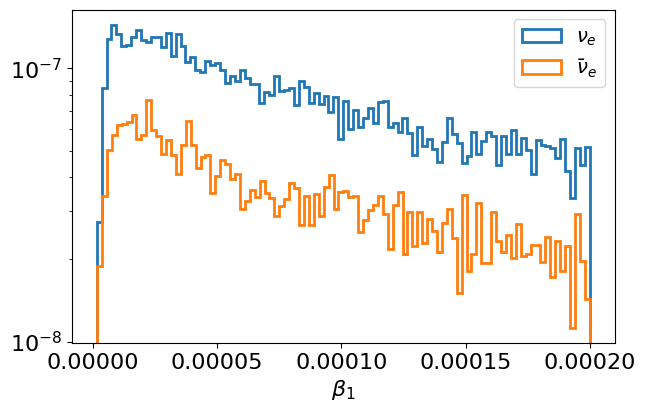

In [23]:
plt.hist(nue_cc["Beta1Reco"], bins=100, histtype='step', weights=nue_cc['I3MCWeightDict.weight'], log=True, lw=2, label=r'$\nu_e$')
plt.hist(nuebar_cc["Beta1Reco"], bins=100, histtype='step', weights=nuebar_cc['I3MCWeightDict.weight'], log=True, lw=2, label=r'$\bar\nu_e$')

plt.legend()
plt.xlabel(r'$\beta_1$')
plt.show()

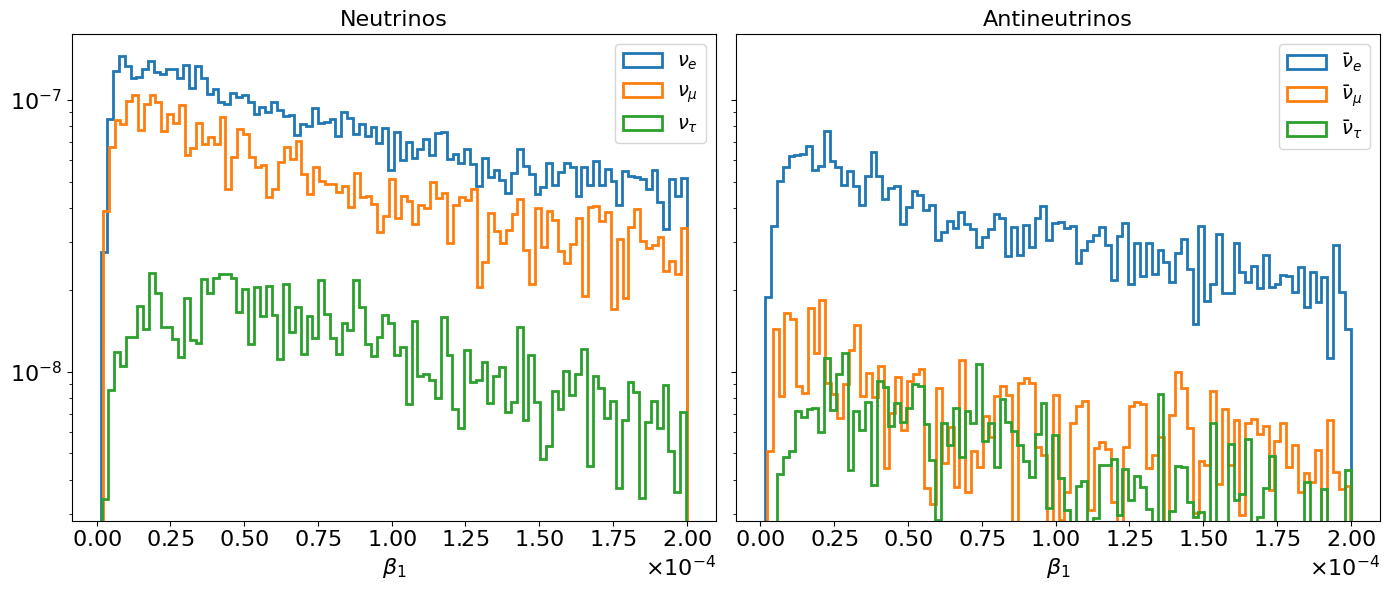

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].hist(nue_cc["Beta1Reco"], bins=100, histtype='step', weights=nue_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_e$')
axes[0].hist(numu_cc["Beta1Reco"], bins=100, histtype='step', weights=numu_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\mu$')
axes[0].hist(nutau_cc["Beta1Reco"], bins=100, histtype='step', weights=nutau_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\tau$')
axes[0].xaxis.set_major_formatter(formatter)
axes[0].legend()
axes[0].set_xlabel(r'$\beta_1$')
axes[0].set_title(r'Neutrinos')

axes[1].hist(nuebar_cc["Beta1Reco"], bins=100, histtype='step', weights=nuebar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_e$')
axes[1].hist(numubar_cc["Beta1Reco"], bins=100, histtype='step', weights=numubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\mu$')
axes[1].hist(nutaubar_cc["Beta1Reco"], bins=100, histtype='step', weights=nutaubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\tau$')
axes[1].xaxis.set_major_formatter(formatter)
axes[1].legend()
axes[1].set_xlabel(r'$\beta_1$')
axes[1].set_title(r'Antineutrinos')

plt.tight_layout()
plt.show()

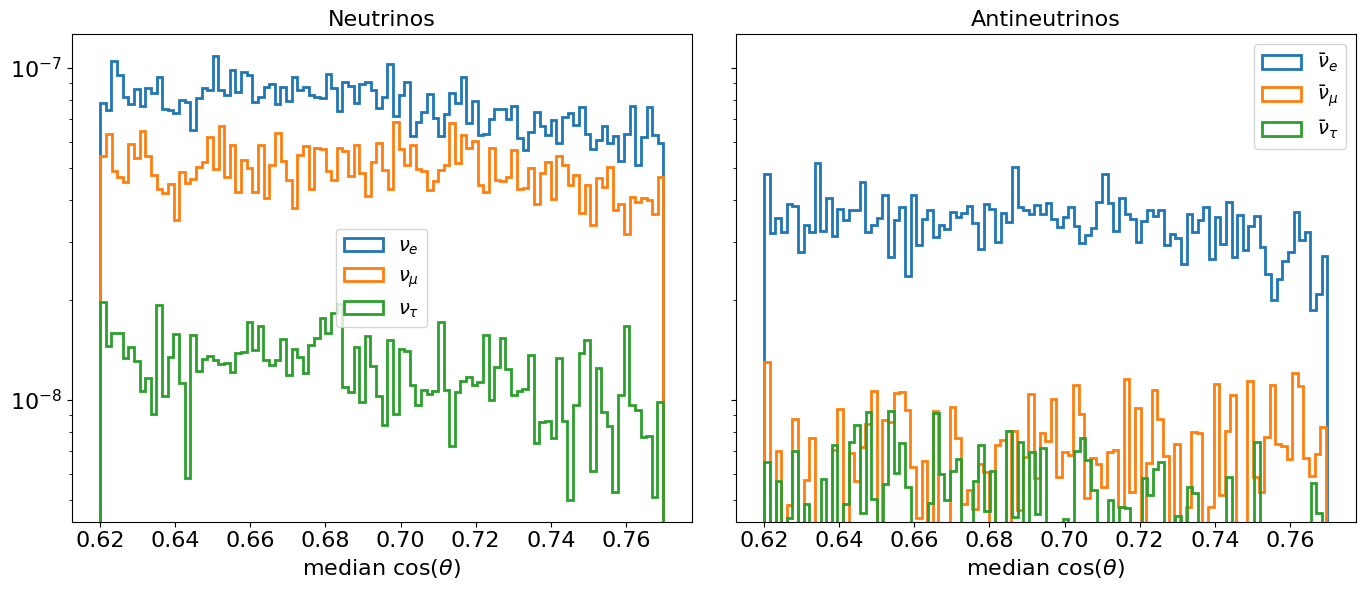

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].hist(nue_cc["MedianAngle"], bins=100, histtype='step', weights=nue_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_e$')
axes[0].hist(numu_cc["MedianAngle"], bins=100, histtype='step', weights=numu_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\mu$')
axes[0].hist(nutau_cc["MedianAngle"], bins=100, histtype='step', weights=nutau_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\tau$')
axes[0].legend()
axes[0].set_xlabel(r'median $\cos(\theta)$')
axes[0].set_title(r'Neutrinos')

axes[1].hist(nuebar_cc["MedianAngle"], bins=100, histtype='step', weights=nuebar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_e$')
axes[1].hist(numubar_cc["MedianAngle"], bins=100, histtype='step', weights=numubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\mu$')
axes[1].hist(nutaubar_cc["MedianAngle"], bins=100, histtype='step', weights=nutaubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\tau$')
#axes[1].set_ylim(1e-9, 0.0000002)
axes[1].legend()
axes[1].set_xlabel(r'median $\cos(\theta)$')
axes[1].set_title(r'Antineutrinos')

plt.tight_layout()
plt.show()

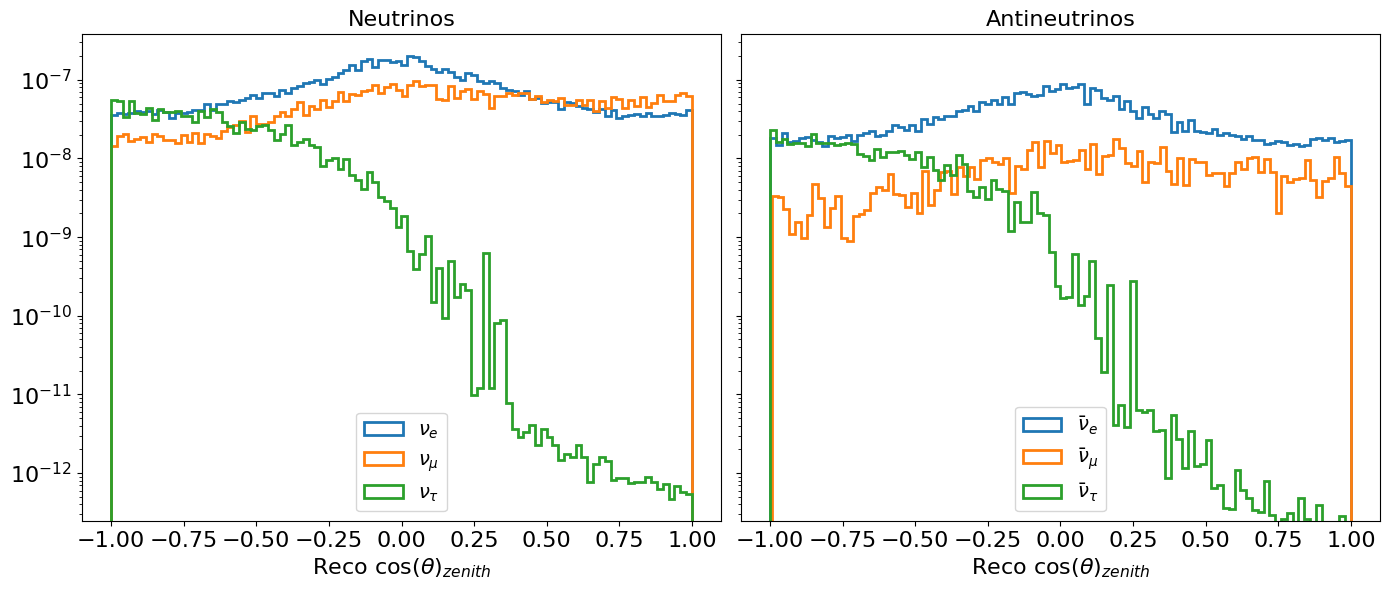

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].hist(nue_cc["graphnet_dynedge_direction_reconstruction_coszen_pred"], bins=100, histtype='step', weights=nue_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_e$')
axes[0].hist(numu_cc["graphnet_dynedge_direction_reconstruction_coszen_pred"], bins=100, histtype='step', weights=numu_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\mu$')
axes[0].hist(nutau_cc["graphnet_dynedge_direction_reconstruction_coszen_pred"], bins=100, histtype='step', weights=nutau_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\tau$')
axes[0].legend()
axes[0].set_xlabel(r'Reco $\cos(\theta)_{zenith}$')
axes[0].set_title(r'Neutrinos')

axes[1].hist(nuebar_cc["graphnet_dynedge_direction_reconstruction_coszen_pred"], bins=100, histtype='step', weights=nuebar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_e$')
axes[1].hist(numubar_cc["graphnet_dynedge_direction_reconstruction_coszen_pred"], bins=100, histtype='step', weights=numubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\mu$')
axes[1].hist(nutaubar_cc["graphnet_dynedge_direction_reconstruction_coszen_pred"], bins=100, histtype='step', weights=nutaubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\tau$')
axes[1].legend()
axes[1].set_xlabel(r'Reco $\cos(\theta)_{zenith}$')
axes[1].set_title(r'Antineutrinos')

plt.tight_layout()
plt.show()

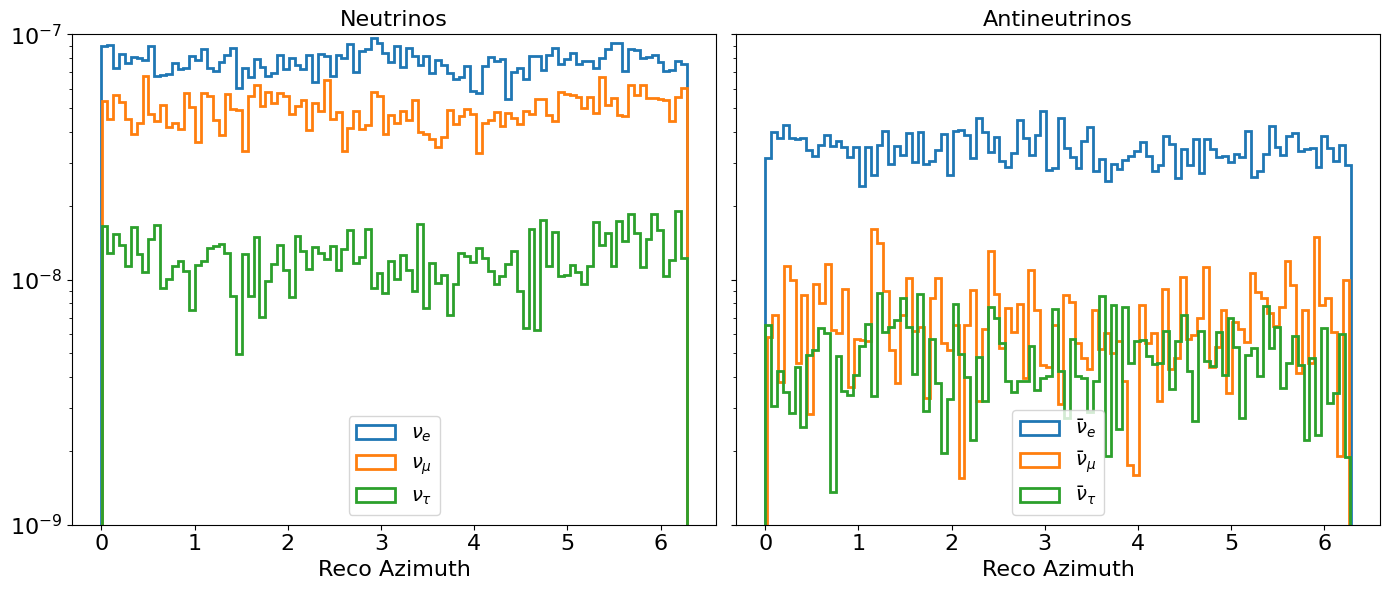

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].hist(nue_cc["graphnet_dynedge_direction_reconstruction_azimuth_pred"], bins=100, histtype='step', weights=nue_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_e$')
axes[0].hist(numu_cc["graphnet_dynedge_direction_reconstruction_azimuth_pred"], bins=100, histtype='step', weights=numu_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\mu$')
axes[0].hist(nutau_cc["graphnet_dynedge_direction_reconstruction_azimuth_pred"], bins=100, histtype='step', weights=nutau_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\tau$')
axes[0].legend()
axes[0].set_xlabel(r'Reco Azimuth')
axes[0].set_title(r'Neutrinos')

axes[1].hist(nuebar_cc["graphnet_dynedge_direction_reconstruction_azimuth_pred"], bins=100, histtype='step', weights=nuebar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_e$')
axes[1].hist(numubar_cc["graphnet_dynedge_direction_reconstruction_azimuth_pred"], bins=100, histtype='step', weights=numubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\mu$')
axes[1].hist(nutaubar_cc["graphnet_dynedge_direction_reconstruction_azimuth_pred"], bins=100, histtype='step', weights=nutaubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\tau$')
#axes[1].set_ylim(1e-8, 1e-4)
axes[1].set_ylim(1e-9, 1e-7)
axes[1].legend()
axes[1].set_xlabel(r'Reco Azimuth')
axes[1].set_title(r'Antineutrinos')

plt.tight_layout()
plt.show()

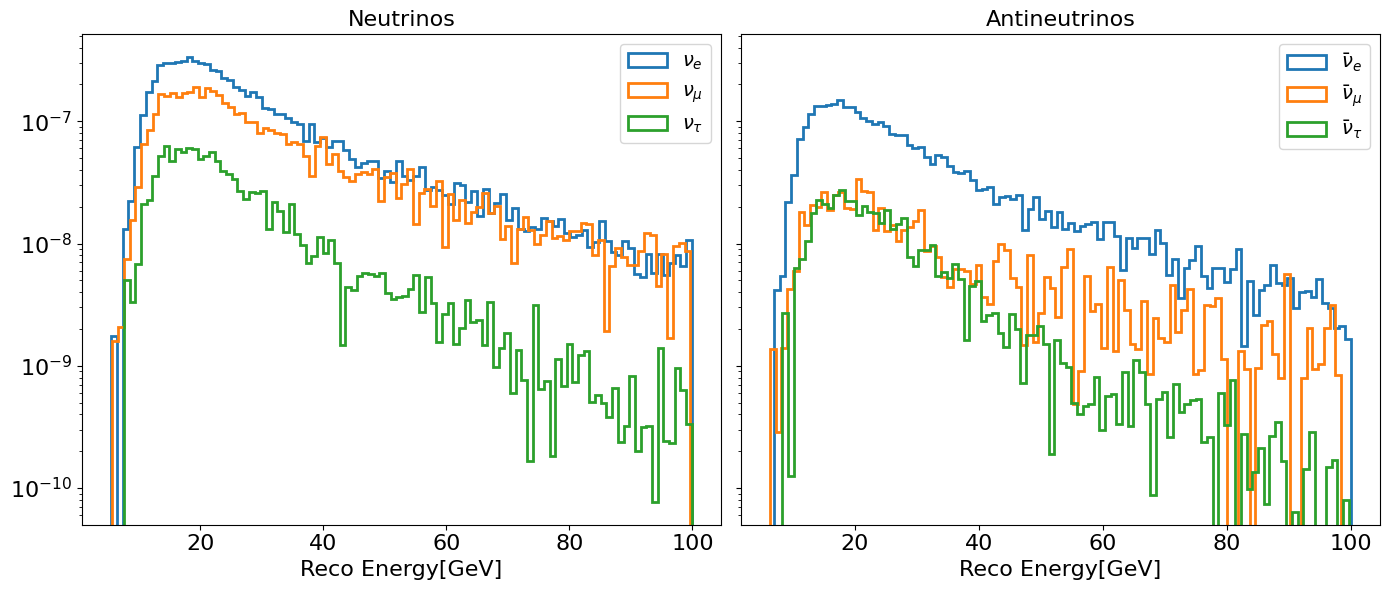

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].hist(nue_cc["graphnet_dynedge_energy_reconstruction_energy_pred"], bins=100, histtype='step', weights=nue_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_e$')
axes[0].hist(numu_cc["graphnet_dynedge_energy_reconstruction_energy_pred"], bins=100, histtype='step', weights=numu_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\mu$')
axes[0].hist(nutau_cc["graphnet_dynedge_energy_reconstruction_energy_pred"], bins=100, histtype='step', weights=nutau_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\tau$')
axes[0].legend()
axes[0].set_xlabel(r'Reco Energy[GeV]')
axes[0].set_title(r'Neutrinos')

axes[1].hist(nuebar_cc["graphnet_dynedge_energy_reconstruction_energy_pred"], bins=100, histtype='step', weights=nuebar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_e$')
axes[1].hist(numubar_cc["graphnet_dynedge_energy_reconstruction_energy_pred"], bins=100, histtype='step', weights=numubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\mu$')
axes[1].hist(nutaubar_cc["graphnet_dynedge_energy_reconstruction_energy_pred"], bins=100, histtype='step', weights=nutaubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\tau$')
axes[1].legend()
axes[1].set_xlabel(r'Reco Energy[GeV]')
axes[1].set_title(r'Antineutrinos')

plt.tight_layout()
plt.show()

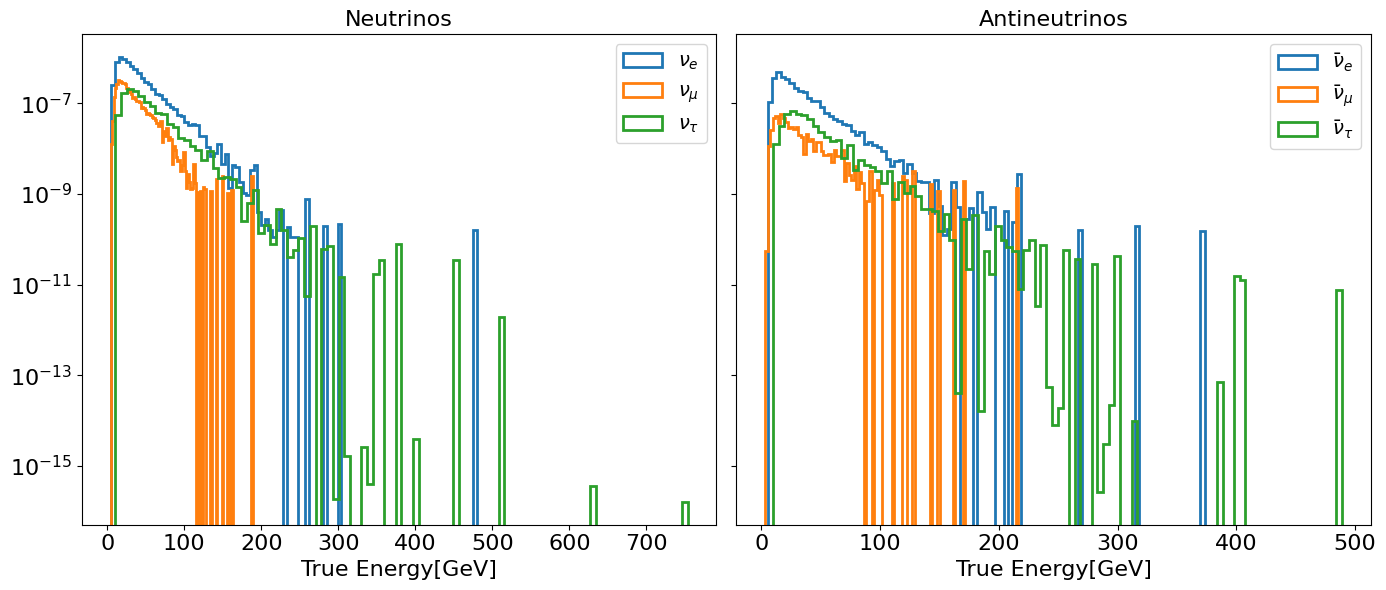

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].hist(nue_cc["true_cascade_energy"][:] + nue_cc["true_hadronic_energy"][:], bins=100, histtype='step', weights=nue_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_e$')
axes[0].hist(numu_cc["true_track_energy"][:] + numu_cc["true_hadronic_energy"][:], bins=100, histtype='step', weights=numu_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\mu$')
axes[0].hist(nutau_cc["true_cascade_energy"][:] + nutau_cc["true_hadronic_energy"][:], bins=100, histtype='step', weights=nutau_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\tau$')
axes[0].legend()
axes[0].set_xlabel(r'True Energy[GeV]')
axes[0].set_title(r'Neutrinos')

axes[1].hist(nuebar_cc["true_cascade_energy"][:] + nuebar_cc["true_hadronic_energy"][:], bins=100, histtype='step', weights=nuebar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_e$')
axes[1].hist(numubar_cc["true_track_energy"][:] + numubar_cc["true_hadronic_energy"][:], bins=100, histtype='step', weights=numubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\mu$')
axes[1].hist(nutaubar_cc["true_cascade_energy"][:] + nutaubar_cc["true_hadronic_energy"][:], bins=100, histtype='step', weights=nutaubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\tau$')
axes[1].legend()
axes[1].set_xlabel(r'True Energy[GeV]')
axes[1].set_title(r'Antineutrinos')

plt.tight_layout()
plt.show()

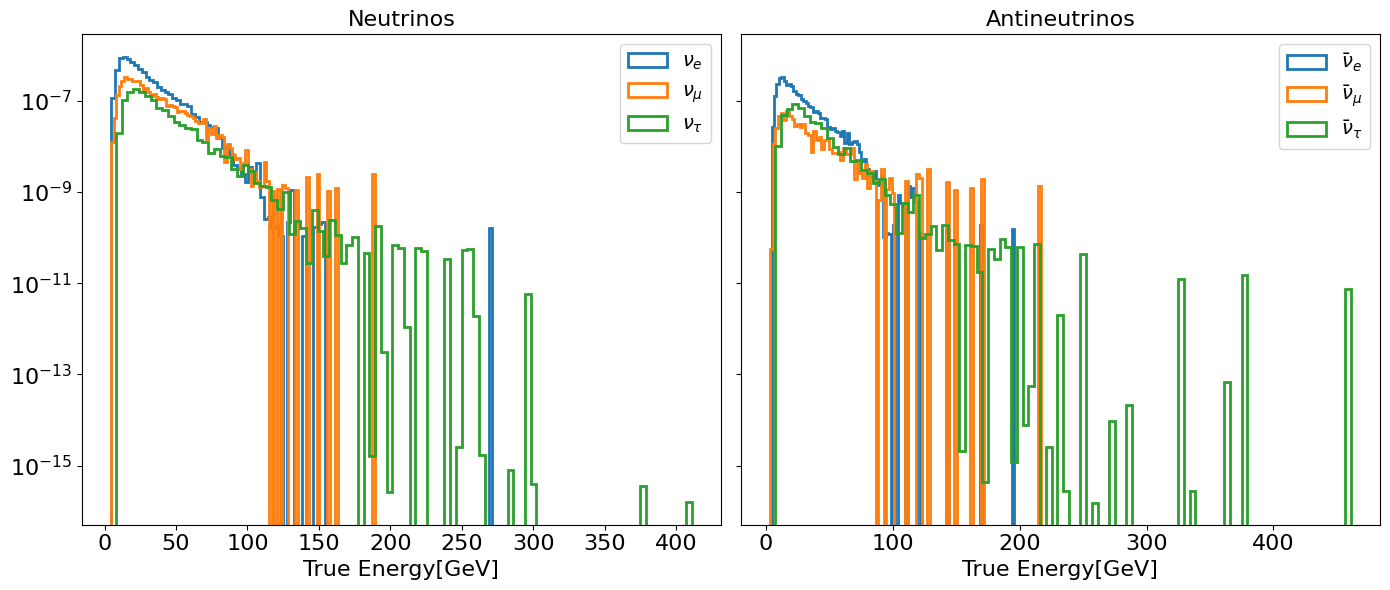

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].hist(nue_cc["MCInIcePrimary.energy"], bins=100, histtype='step', weights=nue_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_e$')
axes[0].hist(numu_cc["MCInIcePrimary.energy"], bins=100, histtype='step', weights=numu_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\mu$')
axes[0].hist(nutau_cc["MCInIcePrimary.energy"], bins=100, histtype='step', weights=nutau_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\tau$')
axes[0].legend()
axes[0].set_xlabel(r'True Energy[GeV]')
axes[0].set_title(r'Neutrinos')

axes[1].hist(nuebar_cc["MCInIcePrimary.energy"], bins=100, histtype='step', weights=nuebar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_e$')
axes[1].hist(numubar_cc["MCInIcePrimary.energy"], bins=100, histtype='step', weights=numubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\mu$')
axes[1].hist(nutaubar_cc["MCInIcePrimary.energy"], bins=100, histtype='step', weights=nutaubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\tau$')
#axes[1].set_ylim(1e-8, 0.000051)
axes[1].legend()
axes[1].set_xlabel(r'True Energy[GeV]')
axes[1].set_title(r'Antineutrinos')

plt.tight_layout()
plt.show()

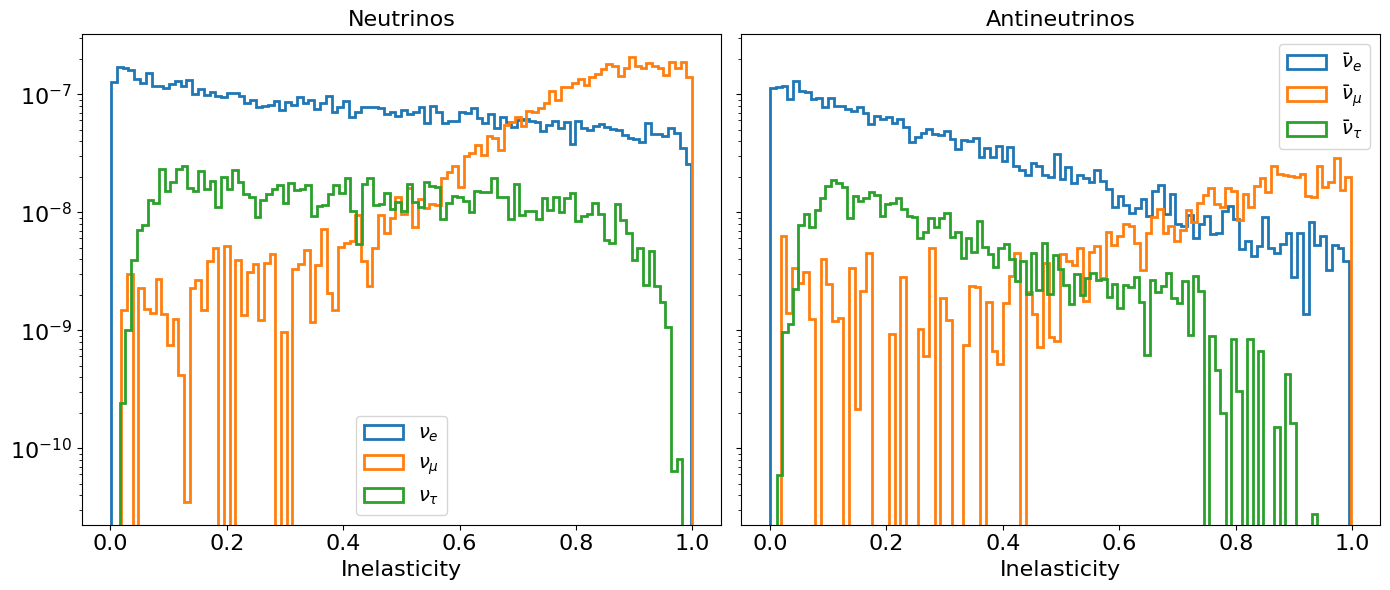

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].hist((nue_cc["true_hadronic_energy"][:])/nue_cc["MCInIcePrimary.energy"][:], bins=100, histtype='step', weights=nue_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_e$')
axes[0].hist((numu_cc["true_hadronic_energy"][:])/numu_cc["MCInIcePrimary.energy"][:], bins=100, histtype='step', weights=numu_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\mu$')
axes[0].hist((nutau_cc["true_hadronic_energy"][:])/nutau_cc["MCInIcePrimary.energy"][:], bins=100, histtype='step', weights=nutau_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\tau$')
axes[0].legend()
axes[0].set_xlabel(r'Inelasticity')
axes[0].set_title(r'Neutrinos')

axes[1].hist((nuebar_cc["true_hadronic_energy"][:])/nuebar_cc["MCInIcePrimary.energy"][:], bins=100, histtype='step', weights=nuebar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_e$')
axes[1].hist((numubar_cc["true_hadronic_energy"][:])/numubar_cc["MCInIcePrimary.energy"][:], bins=100, histtype='step', weights=numubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\mu$')
axes[1].hist((nutaubar_cc["true_hadronic_energy"][:])/nutaubar_cc["MCInIcePrimary.energy"][:], bins=100, histtype='step', weights=nutaubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\tau$')
axes[1].legend()
axes[1].set_xlabel(r'Inelasticity')
axes[1].set_title(r'Antineutrinos')

plt.tight_layout()
plt.show()

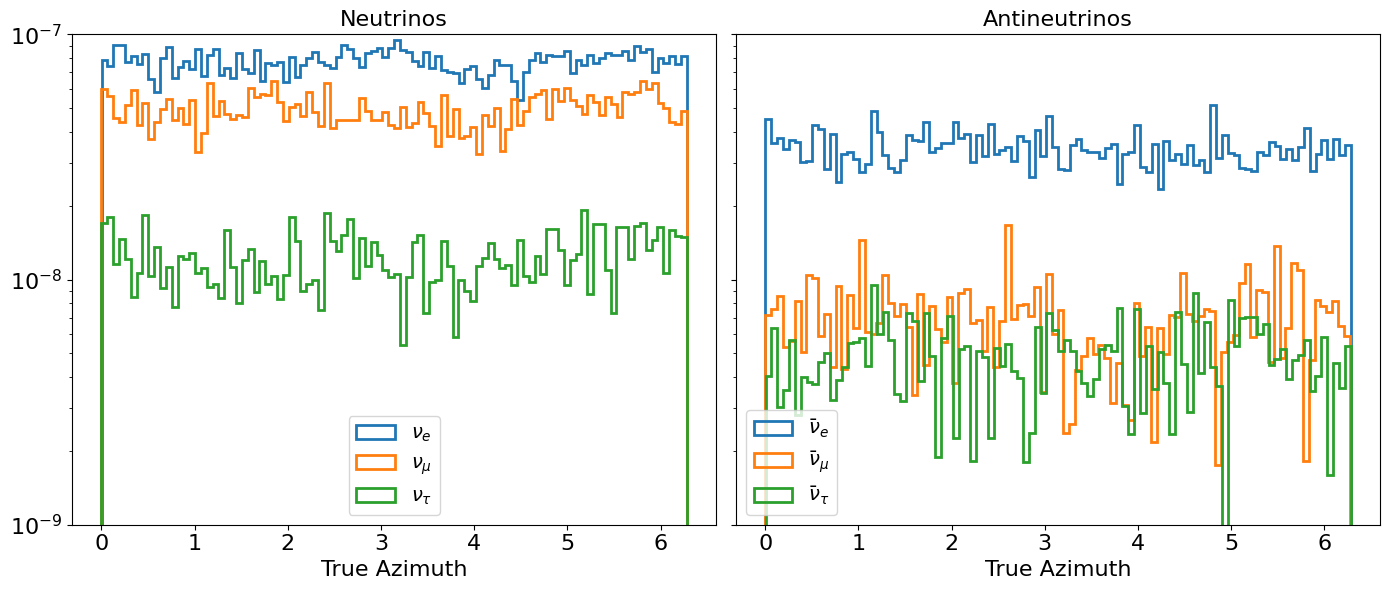

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].hist(nue_cc["MCInIcePrimary.dir.azimuth"], bins=100, histtype='step', weights=nue_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_e$')
axes[0].hist(numu_cc["MCInIcePrimary.dir.azimuth"], bins=100, histtype='step', weights=numu_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\mu$')
axes[0].hist(nutau_cc["MCInIcePrimary.dir.azimuth"], bins=100, histtype='step', weights=nutau_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\tau$')
axes[0].legend()
axes[0].set_xlabel(r'True Azimuth')
axes[0].set_title(r'Neutrinos')

axes[1].hist(nuebar_cc["MCInIcePrimary.dir.azimuth"], bins=100, histtype='step', weights=nuebar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_e$')
axes[1].hist(numubar_cc["MCInIcePrimary.dir.azimuth"], bins=100, histtype='step', weights=numubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\mu$')
axes[1].hist(nutaubar_cc["MCInIcePrimary.dir.azimuth"], bins=100, histtype='step', weights=nutaubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\tau$')
#axes[1].set_ylim(1e-8, 0.000051)
axes[1].set_ylim(1e-9, 1e-7)
axes[1].legend()
axes[1].set_xlabel(r'True Azimuth')
axes[1].set_title(r'Antineutrinos')

plt.tight_layout()
plt.show()

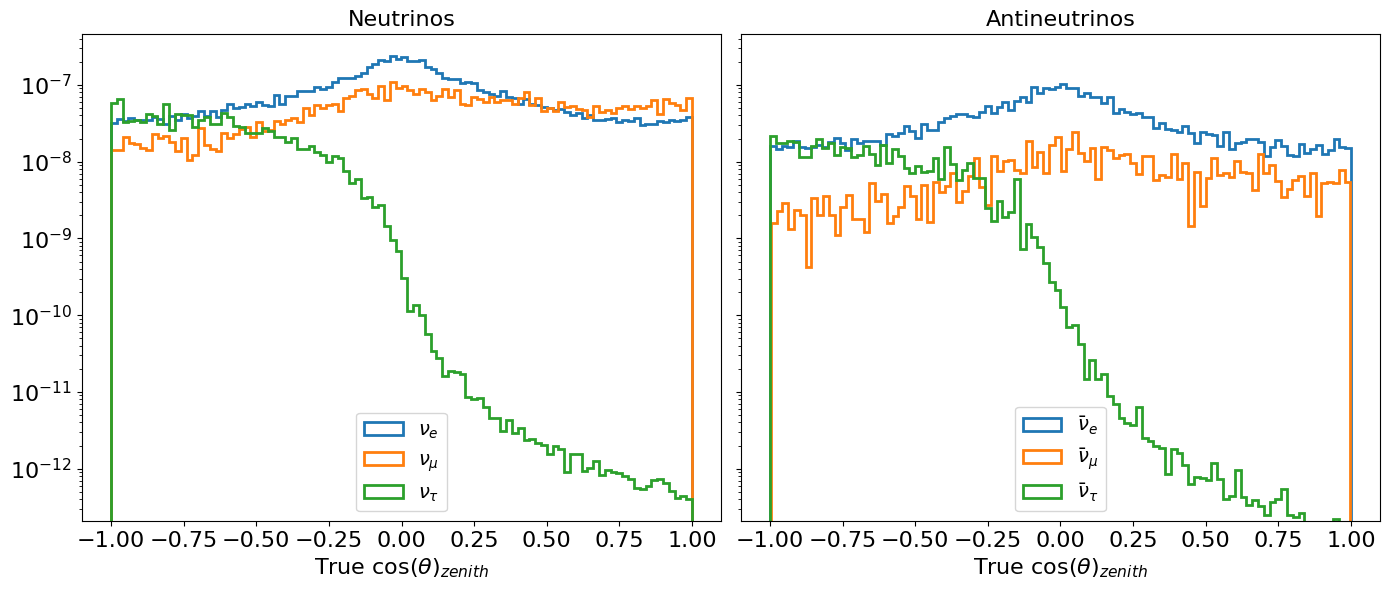

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].hist(nue_cc["MCInIcePrimary.dir.coszen"], bins=100, histtype='step', weights=nue_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_e$')
axes[0].hist(numu_cc["MCInIcePrimary.dir.coszen"], bins=100, histtype='step', weights=numu_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\mu$')
axes[0].hist(nutau_cc["MCInIcePrimary.dir.coszen"], bins=100, histtype='step', weights=nutau_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\tau$')
axes[0].legend()
axes[0].set_xlabel(r'True $\cos(\theta)_{zenith}$')
axes[0].set_title(r'Neutrinos')

axes[1].hist(nuebar_cc["MCInIcePrimary.dir.coszen"], bins=100, histtype='step', weights=nuebar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_e$')
axes[1].hist(numubar_cc["MCInIcePrimary.dir.coszen"], bins=100, histtype='step', weights=numubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\mu$')
axes[1].hist(nutaubar_cc["MCInIcePrimary.dir.coszen"], bins=100, histtype='step', weights=nutaubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\tau$')
axes[1].legend()
axes[1].set_xlabel(r'True $\cos(\theta)_{zenith}$')
axes[1].set_title(r'Antineutrinos')

plt.tight_layout()
plt.show()

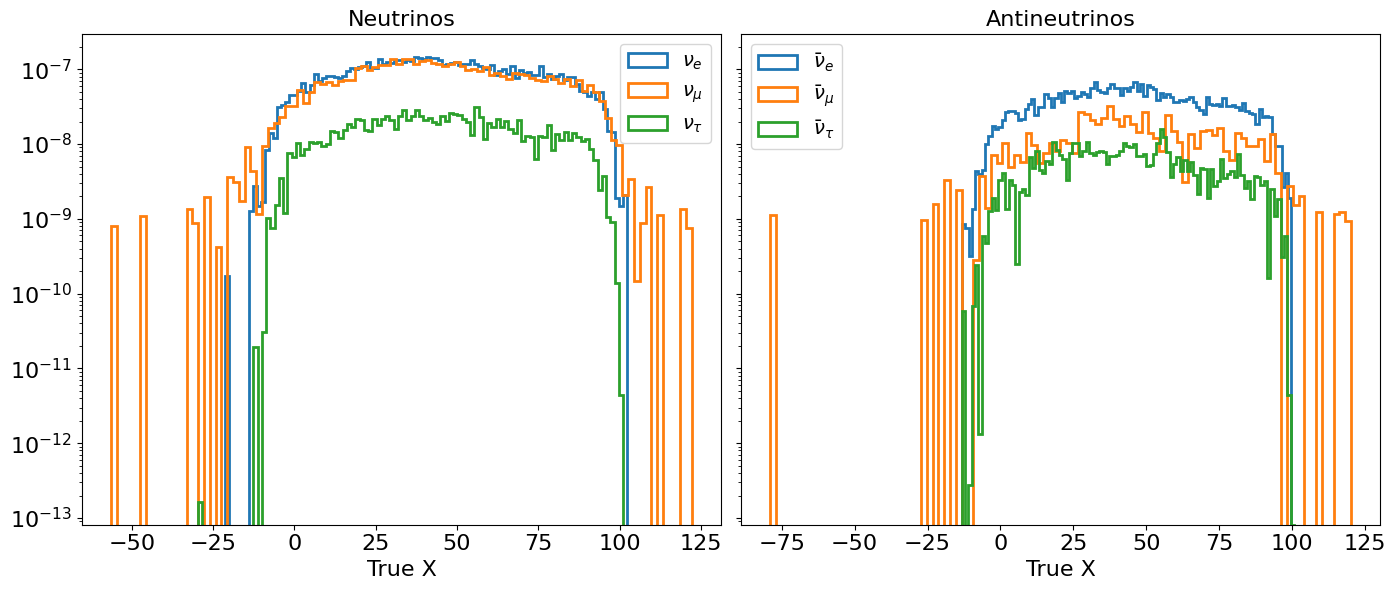

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].hist(nue_cc["MCInIcePrimary.pos.x"], bins=100, histtype='step', weights=nue_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_e$')
axes[0].hist(numu_cc["MCInIcePrimary.pos.x"], bins=100, histtype='step', weights=numu_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\mu$')
axes[0].hist(nutau_cc["MCInIcePrimary.pos.x"], bins=100, histtype='step', weights=nutau_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\tau$')
axes[0].legend()
axes[0].set_xlabel(r'True X')
axes[0].set_title(r'Neutrinos')

axes[1].hist(nuebar_cc["MCInIcePrimary.pos.x"], bins=100, histtype='step', weights=nuebar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_e$')
axes[1].hist(numubar_cc["MCInIcePrimary.pos.x"], bins=100, histtype='step', weights=numubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\mu$')
axes[1].hist(nutaubar_cc["MCInIcePrimary.pos.x"], bins=100, histtype='step', weights=nutaubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\tau$')
#axes[1].set_ylim(1e-8, 0.000051)
#axes[1].set_ylim(1e-9, 1e-7)
axes[1].legend()
axes[1].set_xlabel(r'True X')
axes[1].set_title(r'Antineutrinos')

plt.tight_layout()
plt.show()

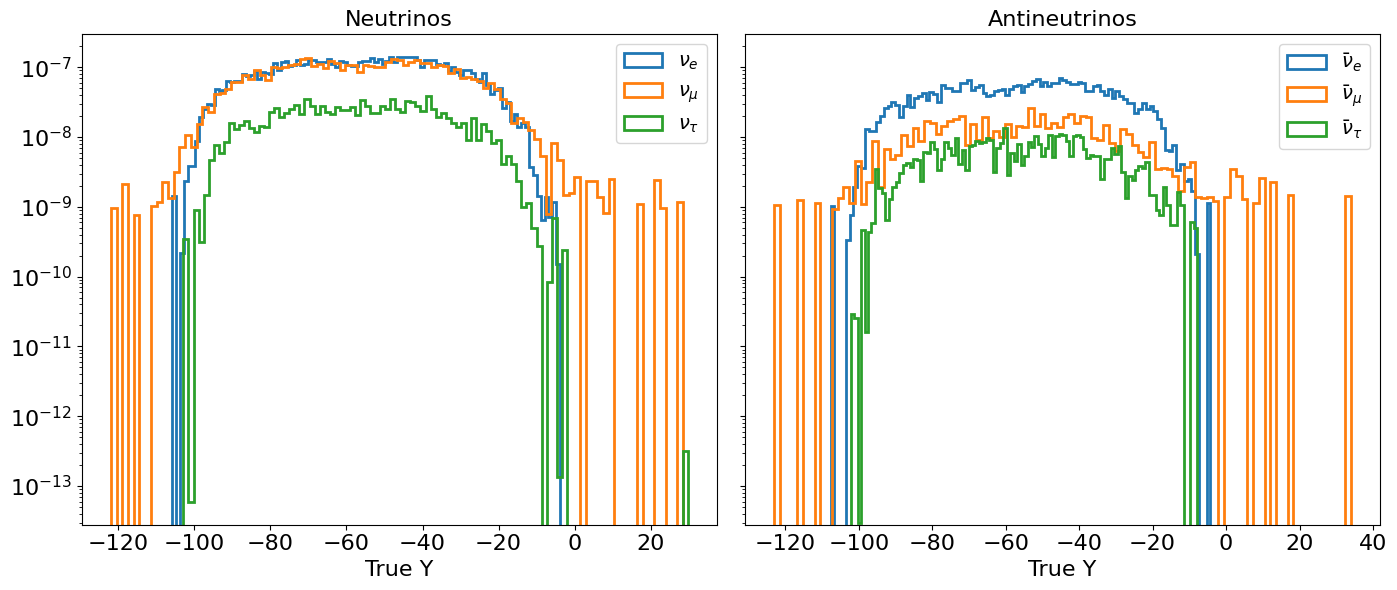

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].hist(nue_cc["MCInIcePrimary.pos.y"], bins=100, histtype='step', weights=nue_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_e$')
axes[0].hist(numu_cc["MCInIcePrimary.pos.y"], bins=100, histtype='step', weights=numu_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\mu$')
axes[0].hist(nutau_cc["MCInIcePrimary.pos.y"], bins=100, histtype='step', weights=nutau_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\tau$')
axes[0].legend()
axes[0].set_xlabel(r'True Y')
axes[0].set_title(r'Neutrinos')

axes[1].hist(nuebar_cc["MCInIcePrimary.pos.y"], bins=100, histtype='step', weights=nuebar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_e$')
axes[1].hist(numubar_cc["MCInIcePrimary.pos.y"], bins=100, histtype='step', weights=numubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\mu$')
axes[1].hist(nutaubar_cc["MCInIcePrimary.pos.y"], bins=100, histtype='step', weights=nutaubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\tau$')
#axes[1].set_ylim(1e-8, 0.000051)
#axes[1].set_ylim(1e-9, 1e-7)
axes[1].legend()
axes[1].set_xlabel(r'True Y')
axes[1].set_title(r'Antineutrinos')

plt.tight_layout()
plt.show()

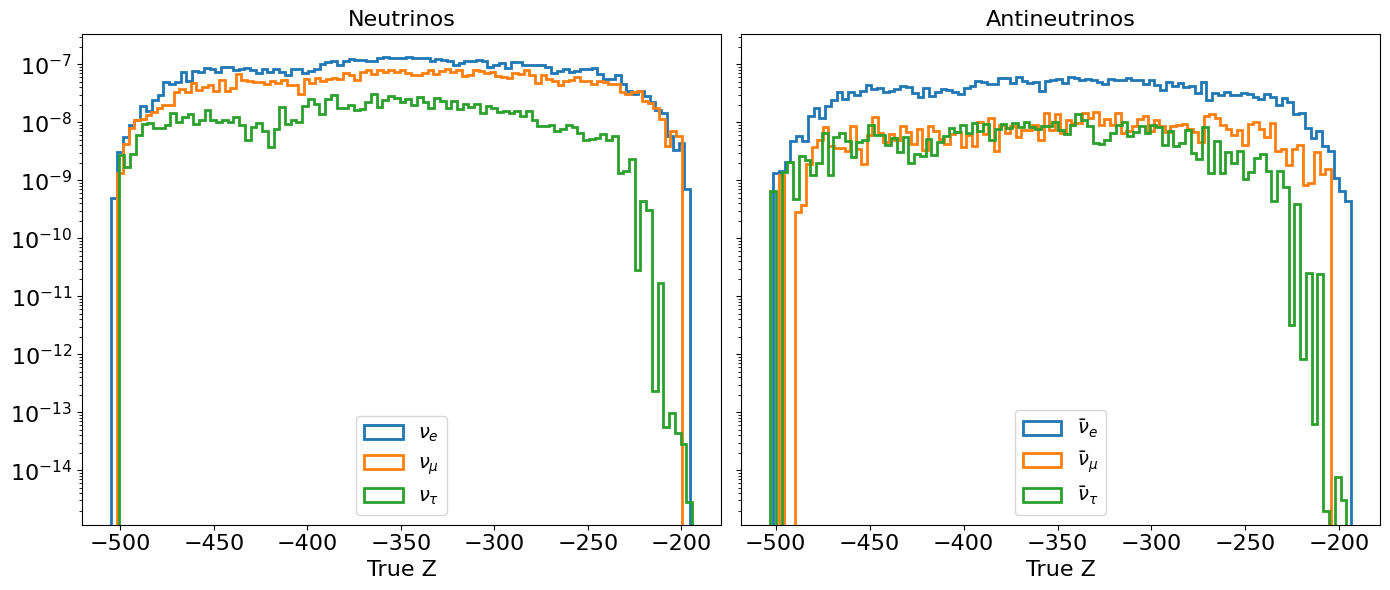

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].hist(nue_cc["MCInIcePrimary.pos.z"], bins=100, histtype='step', weights=nue_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_e$')
axes[0].hist(numu_cc["MCInIcePrimary.pos.z"], bins=100, histtype='step', weights=numu_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\mu$')
axes[0].hist(nutau_cc["MCInIcePrimary.pos.z"], bins=100, histtype='step', weights=nutau_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\nu_\tau$')
axes[0].legend()
axes[0].set_xlabel(r'True Z')
axes[0].set_title(r'Neutrinos')

axes[1].hist(nuebar_cc["MCInIcePrimary.pos.z"], bins=100, histtype='step', weights=nuebar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_e$')
axes[1].hist(numubar_cc["MCInIcePrimary.pos.z"], bins=100, histtype='step', weights=numubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\mu$')
axes[1].hist(nutaubar_cc["MCInIcePrimary.pos.z"], bins=100, histtype='step', weights=nutaubar_cc["I3MCWeightDict.weight"], log=True, lw=2, label=r'$\bar\nu_\tau$')
#axes[1].set_ylim(1e-8, 0.000051)
#axes[1].set_ylim(1e-9, 1e-7)
axes[1].legend()
axes[1].set_xlabel(r'True Z')
axes[1].set_title(r'Antineutrinos')

plt.tight_layout()
plt.show()